# <span style="color:#1FCBED"> Averaging after registration to templates </span> </br>

In [1]:
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import glob
import os
import importlib

In [24]:
import os, sys
parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(parent_dir)
print(parent_dir)

c:\Users\Admin\Documents\msc_project\Image-processing-strategies


In [34]:
import monkey_tools.roi_correlation
importlib.reload(monkey_tools.roi_correlation)

from monkey_tools.roi_correlation import compare_mwf_qsm  # re-import updated function

## <span style="color:#EEF527"> SC-QSM to PAM50 template </span> </br>

In [4]:
data_dir = r"R:\soothsayer\sc_qsm\sc_qsm\neuropoly_data\registered_2_PAM50"
files = sorted(glob.glob(os.path.join(data_dir, "chi_*_registered_chimap_cropped.nii.gz")))

In [5]:
ref_img = nib.load(files[0])

In [6]:
stack = np.stack([nib.load(f).get_fdata() for f in files], axis=-1)
print(f"Loaded {stack.shape[-1]} participants, volume shape: {stack.shape[:3]}")

Loaded 8 participants, volume shape: (141, 141, 83)


In [7]:
mean_map = np.mean(stack, axis=-1)

In [9]:
mean_img = nib.Nifti1Image(mean_map, ref_img.affine, ref_img.header)
mean_outpath = os.path.join(data_dir, "simple_group_mean_chimap_cropped.nii.gz")
nib.save(mean_img, mean_outpath)

In [ ]:
# Now, if you  

In [13]:
from nibabel.processing import resample_from_to
atlas = img
pam50 = nib.load(r'C:\Users\Admin\spinalcordtoolbox\data\PAM50\template\PAM50_t1.nii.gz')

# Step 1: fix the origin in the affine
aff = atlas.affine.copy()
aff[0, 3] = 35.0
aff[1, 3] = -81.22
aff[2, 3] = -561.84

origin_fixed = nib.Nifti1Image(atlas.get_fdata(), aff, atlas.header)

# Step 2: resample onto PAM50 grid (same voxel size, just forces identical dimensions + origin)
resampled = resample_from_to(origin_fixed, pam50, order=1)  # order=0 if label map

nib.save(resampled, r"R:\soothsayer\msc_data\MWI_spinal_cord_atlases\MWF_atlas_originfixed_resampled.nii.gz")


Spearman ρ = -0.358, p = 0.0
Pearson  r = -0.389, p = 0.0


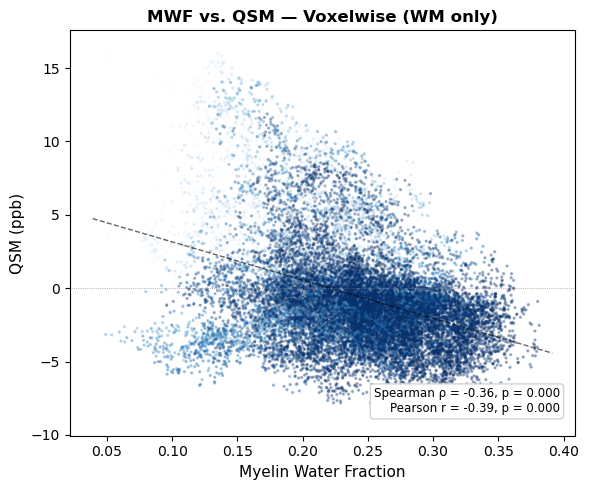

Saved to: R:\soothsayer\sc_qsm\sc_qsm\neuropoly_data\registered_2_PAM50\correlation.png


In [35]:
# Now we can calculate some metrics on the cropped images!
mwf_template = r"R:\soothsayer\sc_qsm\sc_qsm\neuropoly_data\registered_2_PAM50\MWF_atlas_originfixed_resampled_cropped.nii.gz"
gm_template_crop_path = r"R:\soothsayer\sc_qsm\sc_qsm\neuropoly_data\registered_2_PAM50\PAM50_gm_cropped.nii.gz"
wm_template_crop_path = r"R:\soothsayer\sc_qsm\sc_qsm\neuropoly_data\registered_2_PAM50\PAM50_wm_cropped.nii.gz"
correlation_outpath = r"R:\soothsayer\sc_qsm\sc_qsm\neuropoly_data\registered_2_PAM50\correlation.png"

mwf_df = compare_mwf_qsm(mean_outpath, mwf_template, wm_template_crop_path, correlation_outpath, mode='voxelwise')

In [29]:
mwf_data = nib.load(mwf_template).get_fdata()
print(np.unique(mwf_data[mwf_data < 0.01])[:20])

[0.00000000e+00 1.34246209e-11 1.42533975e-11 1.51733584e-11
 1.62971628e-11 1.63566570e-11 1.67202216e-11 1.73268019e-11
 2.04410375e-11 2.11030145e-11 2.14305986e-11 2.17412172e-11
 2.23618587e-11 2.24518686e-11 2.24606961e-11 2.34943267e-11
 2.37975750e-11 2.44511572e-11 2.49518950e-11 2.54649334e-11]
